# 06 — Bicycle model vs actual (Phase 3, Wk 5 Day 2)

The hand-coded single-track bicycle model (`aris.physics.bicycle`) predicts a **single, constant** grip-limited lap time — it has no per-lap inputs yet (no fuel mass, no tyre age, no thermal model, no downforce). We overlay that flat prediction on one of Verstappen's real green-flag stints at Bahrain 2024.

It is **wrong on purpose.** The gap between the flat line and the real laps — and the *shape* of that gap against tyre age — is exactly the residual the Wk-6 ML will learn, fed through the leakage-safe builder the Day-1 tripwire guards.

In [1]:
from pathlib import Path

import fastf1
import matplotlib.pyplot as plt

from aris.physics.bicycle import Car, StintState, bahrain_2024, predict_lap_time
from aris.physics.stint import detect_stints, filter_clean_laps

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CACHE = REPO / "fastf1_cache"
fastf1.Cache.enable_cache(str(CACHE))
print("fastf1", fastf1.__version__)

fastf1 3.8.3


In [2]:
session = fastf1.get_session(2024, "Bahrain", "R")
session.load(telemetry=False, laps=True, weather=False, messages=False)

enriched = detect_stints(session.laps)
clean = filter_clean_laps(enriched)
ver = clean[clean["Driver"] == "VER"].copy()

# pick VER's longest green-flag stint
longest = ver.groupby("StintId").size().idxmax()
stint = ver[ver["StintId"] == longest].sort_values("LapNumber")
compound = stint["Compound"].iloc[0]
print(f"VER stint {longest}: {len(stint)} green laps, compound {compound}")

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for lap_count


...

req            INFO 	Using cached data for _extended_timing_data


req            INFO 	Using cached data for timing_app_data


core           INFO 	Processing timing data...


core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


VER stint 3: 19 green laps, compound SOFT


In [3]:
# the bicycle model: one constant prediction for the whole stint
predicted_s = predict_lap_time(StintState(Car(), bahrain_2024()))
actual_s = stint["LapTimeS"].to_numpy()
tyre_life = stint["TyreLife"].to_numpy()
median_s = stint["LapTimeS"].median()

print(f"bicycle predicted (constant): {predicted_s:.2f} s")
print(f"actual stint median:          {median_s:.2f} s")
print(f"mean residual (actual-pred):  {(actual_s - predicted_s).mean():.2f} s")

bicycle predicted (constant): 111.34 s
actual stint median:          94.67 s
mean residual (actual-pred):  -16.66 s


saved assets\screenshots\wk5-bicycle-vs-actual.png


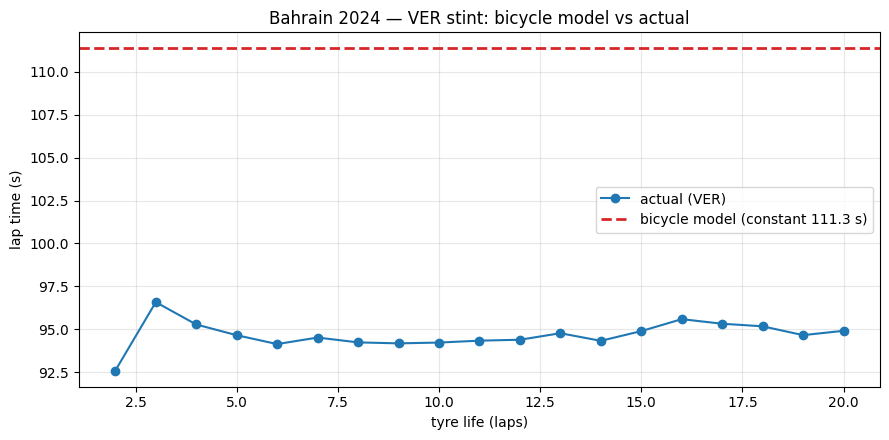

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(tyre_life, actual_s, "o-", color="#1f77b4", label="actual (VER)")
ax.axhline(predicted_s, color="#d62728", ls="--", lw=2,
           label=f"bicycle model (constant {predicted_s:.1f} s)")
ax.set_xlabel("tyre life (laps)")
ax.set_ylabel("lap time (s)")
ax.set_title("Bahrain 2024 — VER stint: bicycle model vs actual")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
out = REPO / "assets" / "screenshots" / "wk5-bicycle-vs-actual.png"
fig.savefig(out, dpi=110, bbox_inches="tight")
print("saved", out.relative_to(REPO))

## Where the model is wrong — the residual map for Wk 6

The flat red line is the entire bicycle model: no per-lap dynamics. The real laps depart from it in three structured ways, and **structure is learnable signal**:

1. **Cold-tyre effect** — the first lap or two of the stint sit high (warming the compound into its working window). The model has no thermal state.
2. **Fuel burn** — the car sheds ~1.6 kg/lap; lighter ⇒ faster, a gentle downward drift across the stint. The Day-2 model is mass-invariant (grip-limited cornering cancels mass), so it misses this entirely — Day 3 adds the linear fuel term.
3. **Tyre degradation** — late in the stint laps climb again as grip falls off. No deg model here.

Below: the residual `actual − predicted` against tyre life. Its slope and curvature are what the Wk-6 residual model is trained to reproduce.

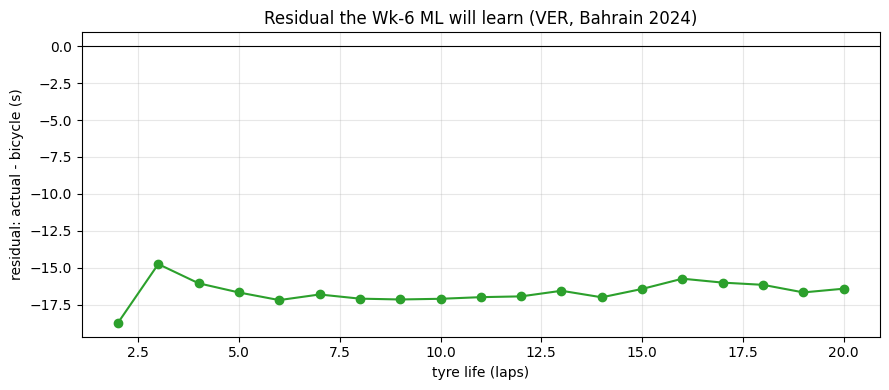

In [5]:
residual = actual_s - predicted_s
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tyre_life, residual, "o-", color="#2ca02c")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("tyre life (laps)")
ax.set_ylabel("residual: actual - bicycle (s)")
ax.set_title("Residual the Wk-6 ML will learn (VER, Bahrain 2024)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Day 3 — fuel-burn + pit-loss terms

Two linear corrections on top of the physics. **Fuel:** the car carries ~110 kg at the start and burns ~1.7 kg/lap; at ~0.03 s per kg, a full tank costs ~3 s vs empty. **Pit-loss:** an in/out lap costs ~21 s at Bahrain. We model fuel across the whole race so this (final) stint correctly sits at low fuel, then re-score.

In [6]:
from aris.eval.scoring import mae

START_FUEL_KG, BURN_PER_LAP_KG = 110.0, 1.7
lap_no = stint["LapNumber"].to_numpy()
fuel_kg = (START_FUEL_KG - BURN_PER_LAP_KG * (lap_no - 1)).clip(min=0)

track = bahrain_2024()
pred_base = [predicted_s] * len(actual_s)
pred_fuel = [predict_lap_time(StintState(Car(), track, fuel_kg=f)) for f in fuel_kg]

mae_base = mae(actual_s, pred_base)
mae_fuel = mae(actual_s, pred_fuel)
print(f"fuel over this stint: {fuel_kg.max():.0f} -> {fuel_kg.min():.0f} kg")
print(f"MAE physics-only:     {mae_base:.2f} s")
print(f"MAE + fuel term:      {mae_fuel:.2f} s")
full = predict_lap_time(StintState(Car(), track, fuel_kg=100.0))
green_ref = predict_lap_time(StintState(Car(), track, fuel_kg=30.0))
pit = predict_lap_time(StintState(Car(), track, fuel_kg=30.0, pit_lap=True))
print(f"full-tank (100 kg) lap: {full:.2f} s  (+{full - predicted_s:.2f} vs empty)")
print(f"in/out (pit) lap:       {pit:.2f} s  (+{pit - green_ref:.2f} pit-loss)")

fuel over this stint: 45 -> 15 kg
MAE physics-only:     16.66 s
MAE + fuel term:      17.56 s
full-tank (100 kg) lap: 114.34 s  (+3.00 vs empty)
in/out (pit) lap:       133.24 s  (+21.00 pit-loss)


saved assets\screenshots\wk5-bicycle-fuel.png


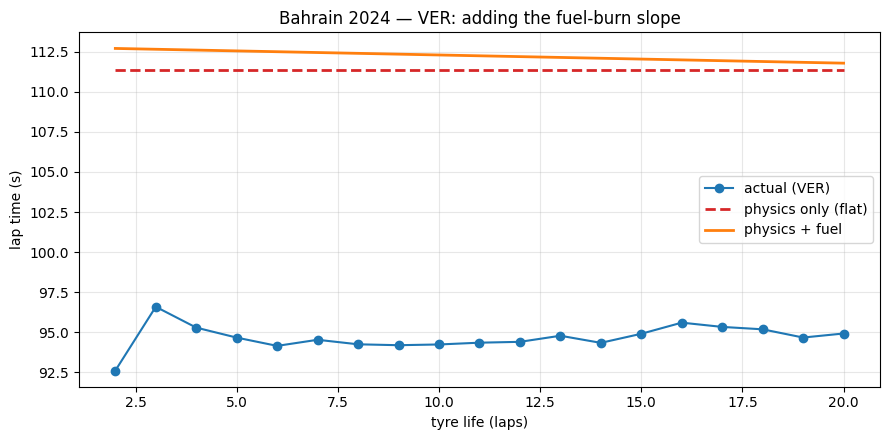

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(tyre_life, actual_s, "o-", color="#1f77b4", label="actual (VER)")
ax.plot(tyre_life, pred_base, "--", color="#d62728", lw=2, label="physics only (flat)")
ax.plot(tyre_life, pred_fuel, "-", color="#ff7f0e", lw=2, label="physics + fuel")
ax.set_xlabel("tyre life (laps)")
ax.set_ylabel("lap time (s)")
ax.set_title("Bahrain 2024 — VER: adding the fuel-burn slope")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
out2 = REPO / "assets" / "screenshots" / "wk5-bicycle-fuel.png"
fig.savefig(out2, dpi=110, bbox_inches="tight")
print("saved", out2.relative_to(REPO))

### Honest read: the fuel term is correct but doesn't help here

The fuel term adds the right *shape* — a gentle downward slope as the tank empties — but it's worth <1 s across this light-fuel final stint, while the error it's competing with is the **~16 s constant bias from missing downforce**. So the MAE barely moves (and, because the base is already too slow, adding any positive fuel penalty nudges it slightly *worse* on this stint). That is exactly the expected outcome, not a failure: a near-constant bias is an intercept the **Wk-6 residual ML learns trivially**, and the fuel/pit-loss terms exist to get the per-lap *structure* right, not the absolute level. Hand-tuning the grip constant to erase the bias would over-fit one stint and generalise badly — the residual model closes it from data instead.